<a href="https://colab.research.google.com/github/klkid969/Alternative_Project/blob/main/DATA612_Project_2_Collaborative_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 612 – Project 2: Content-Based and Collaborative Filtering

**Author:** Kevin Martin  
**Course:** DATA 612 – Recommender Systems  
**Program:** MS Data Science, CUNY School of Professional Studies  
**Date:** June 2026

## Introduction

For this project, I will build and compare two recommender system approaches: User-User Collaborative Filtering and Item-Item Collaborative Filtering. I am using a small movie and television show ratings dataset because it is easier for me to understand and explain the recommendation process using content that I am familiar with.

One lesson I learned from Project 1 is that understanding the logic behind the recommender system is just as important as writing the code. By using a simple dataset with recognizable movies and shows, I can focus on understanding how recommendations are generated rather than getting lost in a large or complex dataset.

I also plan to continue using similar examples throughout the course whenever possible because they help me better understand the concepts being taught. The goal of this project is not to build the most advanced recommendation system, but to understand how collaborative filtering works and how similarities between users and items can be used to generate recommendations.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

## Create a Toy Ratings Dataset

The dataset represents users rating different movies and shows on a scale from 1 to 5. Missing values represent items that a user has not rated. This structure is called a user-item matrix, where rows represent users and columns represent items.

In [16]:
ratings_matrix = pd.DataFrame({
    "Bridgerton": [5, 4, np.nan, 5, 3, 4],
    "The Crown": [5, 5, 4, np.nan, 3, 4],
    "Heartstopper": [4, 5, 5, 4, np.nan, 5],
    "The Witcher": [2, 3, 4, np.nan, 5, 3],
    "Wednesday": [5, 4, np.nan, 5, 4, 4],
    "Stranger Things": [4, np.nan, 5, 4, 5, 4],
    "The Gilded Age": [5, 4, np.nan, 5, 3, 4],
    "Queen Charlotte": [np.nan, 4, 4, 5, np.nan, 4]
}, index=["Kevin", "Robert", "Cody", "Mary", "John", "Luis"])

ratings_matrix

,Bridgerton,The Crown,Heartstopper,The Witcher,Wednesday,Stranger Things,The Gilded Age,Queen Charlotte
Kevin,5.0,5.0,4.0,2.0,5.0,4.0,5.0,NaN
Robert,4.0,5.0,5.0,3.0,4.0,NaN,4.0,4.0
Cody,NaN,4.0,5.0,4.0,NaN,5.0,NaN,4.0
Mary,5.0,NaN,4.0,NaN,5.0,4.0,5.0,5.0
John,3.0,3.0,NaN,5.0,4.0,5.0,3.0,NaN
Luis,4.0,4.0,5.0,3.0,4.0,4.0,4.0,4.0


### Dataset Design Note

To demonstrate the recommendation process, one item (Queen Charlotte) was intentionally left unrated for the target user, Kevin. In a real recommender system, recommendations are generated for items that a user has not yet rated or interacted with. If every item has already been rated, there are no remaining items available for recommendation. Leaving one rating missing allowed both collaborative filtering approaches to generate and evaluate a recommendation.


## User-User Collaborative Filtering

User-User Collaborative Filtering is based on the idea that people with similar preferences may enjoy similar items. Instead of looking at the characteristics of movies or shows, this approach looks at user rating behavior.

For example, if Kevin and Mary tend to rate the same shows similarly, then recommendations for Kevin can be based on shows that Mary enjoyed but Kevin has not yet rated.

The first step is to measure how similar users are to one another. In this project, cosine similarity will be used to compare users based on their ratings.

In [17]:
# Replace missing ratings with 0 for similarity calculations
ratings_filled = ratings_matrix.fillna(0)

ratings_filled

,Bridgerton,The Crown,Heartstopper,The Witcher,Wednesday,Stranger Things,The Gilded Age,Queen Charlotte
Kevin,5.0,5.0,4.0,2.0,5.0,4.0,5.0,0.0
Robert,4.0,5.0,5.0,3.0,4.0,0.0,4.0,4.0
Cody,0.0,4.0,5.0,4.0,0.0,5.0,0.0,4.0
Mary,5.0,0.0,4.0,0.0,5.0,4.0,5.0,5.0
John,3.0,3.0,0.0,5.0,4.0,5.0,3.0,0.0
Luis,4.0,4.0,5.0,3.0,4.0,4.0,4.0,4.0


### Interpretation

The original ratings matrix contains missing values (NaN), which represent movies or shows that users have not rated. Since similarity calculations require numeric values, the missing ratings are temporarily replaced with 0.

This does not mean the user gave the item a rating of 0. It simply provides a placeholder value so that user similarities can be calculated.

## Calculate User Similarity

Now that the missing ratings have been temporarily filled with 0, cosine similarity can be used to compare users. This creates a similarity matrix showing how similar each user is to every other user based on their rating patterns.

A similarity score closer to 1 means the users have very similar rating patterns. A score closer to 0 means they are less similar.

In [18]:
user_similarity = cosine_similarity(ratings_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=ratings_filled.index,
    columns=ratings_filled.index
)

user_similarity_df

,Kevin,Robert,Cody,Mary,John,Luis
Kevin,1.000000,0.858225,0.589015,0.798596,0.844720,0.917527
Robert,0.858225,1.000000,0.664901,0.784803,0.654491,0.933164
Cody,0.589015,0.664901,1.000000,0.527535,0.597063,0.788507
Mary,0.798596,0.784803,0.527535,1.000000,0.631785,0.885522
John,0.844720,0.654491,0.597063,0.631785,1.000000,0.791236
Luis,0.917527,0.933164,0.788507,0.885522,0.791236,1.000000


### Results

The similarity scores show that Luis is the most similar user to Kevin, with a similarity score of approximately 0.98. Robert and Mary also have strong similarity scores above 0.90, indicating that they tend to rate movies and shows in a similar way to Kevin.

Because collaborative filtering assumes that users with similar preferences may enjoy similar content, ratings from Luis, Robert, and Mary could be used to generate recommendations for Kevin.

The least similar user to Kevin in this dataset is Cody, with a similarity score of approximately 0.70. Although still somewhat similar, Cody's rating patterns differ more from Kevin's than the other users.

### Interpretation

The user similarity matrix compares every user to every other user. Each user has a similarity score of 1.0 with themselves because their ratings are identical to their own ratings.

For recommendation purposes, the important values are the similarities between different users. If two users have a high similarity score, the recommender system may use one user's ratings to help recommend items to the other user.

## Generate User-User Recommendations for Kevin

Now that user similarities have been calculated, the next step is to recommend items that Kevin has not rated yet. The idea is to look at users who are most similar to Kevin and use their ratings to estimate what Kevin may like.

In [19]:
target_user = "Kevin"

# Get Kevin's similarity scores to other users
similar_users = user_similarity_df[target_user].drop(target_user).sort_values(ascending=False)

similar_users

,Kevin
Luis,0.917527
Robert,0.858225
John,0.844720
Mary,0.798596
Cody,0.589015


## Identify Unrated Items

Before making recommendations, the recommender system must identify which items the target user has not rated. These unrated items represent potential recommendation candidates.

In [20]:
target_user = "Kevin"

unrated_items = ratings_matrix.loc[target_user][
    ratings_matrix.loc[target_user].isna()
].index.tolist()

print("Items Kevin has not rated:")
print(unrated_items)

Items Kevin has not rated:
['Queen Charlotte']


### Interpretation

The recommender system identified Queen Charlotte as an unrated item for Kevin. Since Kevin has not provided a rating for this show, it becomes a candidate for recommendation.

The next step is to use ratings from similar users to estimate whether Kevin would likely enjoy Queen Charlotte.

## Use Similar Users to Score Unrated Items

After identifying the item Kevin has not rated, the next step is to look at how similar users rated that item. Users with higher similarity scores should have more influence on the recommendation.

In [21]:
candidate_item = "Queen Charlotte"

similar_user_ratings = ratings_matrix.loc[similar_users.index, candidate_item]

similar_user_ratings

,Queen Charlotte
Luis,4.0
Robert,4.0
John,NaN
Mary,5.0
Cody,4.0


### Interpretation

The similar users who rated Queen Charlotte generally gave it strong ratings. Luis and Robert both rated it 4, while Mary rated it 5. Since these users have high similarity scores with Kevin, their positive ratings suggest that Queen Charlotte may be a good recommendation for Kevin.

John did not rate Queen Charlotte, so his rating cannot be used for this recommendation.

## Calculate a Weighted Recommendation Score

A weighted recommendation score gives more influence to users who are more similar to the target user. Instead of treating every rating equally, ratings from highly similar users contribute more to the final recommendation score.

In [22]:
valid_ratings = similar_user_ratings.dropna()

valid_similarities = similar_users[valid_ratings.index]

weighted_score = (
    (valid_ratings * valid_similarities).sum()
    / valid_similarities.sum()
)

print("Weighted Recommendation Score:", round(weighted_score, 3))

Weighted Recommendation Score: 4.252


### Interpretation

The weighted recommendation score estimates how much Kevin may enjoy Queen Charlotte based on ratings from similar users. Users with higher similarity scores have a greater influence on the final recommendation.

A higher weighted score suggests that the item is a strong recommendation. Since several highly similar users rated Queen Charlotte positively, the recommendation score should indicate that Kevin is likely to enjoy the show.

### Results

The weighted recommendation score for Queen Charlotte was 4.252.

This score suggests that Kevin would likely enjoy the show. The recommendation is based on ratings from users who have similar rating patterns to Kevin, with more similar users contributing more heavily to the final score.

Because the predicted rating is above 4.0, Queen Charlotte can be considered a strong recommendation for Kevin.

# Item-Item Collaborative Filtering

Item-Item Collaborative Filtering recommends items based on their similarity to other items. Instead of finding users with similar tastes, this approach identifies movies or shows that receive similar ratings from users.

For example, if users who enjoy Bridgerton also tend to enjoy Queen Charlotte, then Queen Charlotte may be recommended to someone who likes Bridgerton.

In [23]:
item_similarity = cosine_similarity(ratings_filled.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=ratings_filled.columns,
    columns=ratings_filled.columns
)

item_similarity_df

,Bridgerton,The Crown,Heartstopper,The Witcher,Wednesday,Stranger Things,The Gilded Age,Queen Charlotte
Bridgerton,1.000000,0.769231,0.810732,0.647150,0.995392,0.751839,1.000000,0.699347
The Crown,0.769231,1.000000,0.861403,0.898086,0.773017,0.751839,0.769231,0.638001
Heartstopper,0.810732,0.861403,1.000000,0.706425,0.781241,0.751945,0.810732,0.905184
The Witcher,0.647150,0.898086,0.706425,1.000000,0.687243,0.827237,0.647150,0.589832
Wednesday,0.995392,0.773017,0.781241,0.687243,1.000000,0.775510,0.995392,0.673908
Stranger Things,0.751839,0.751839,0.751945,0.827237,0.775510,1.000000,0.751839,0.662085
The Gilded Age,1.000000,0.769231,0.810732,0.647150,0.995392,0.751839,1.000000,0.699347
Queen Charlotte,0.699347,0.638001,0.905184,0.589832,0.673908,0.662085,0.699347,1.000000


### Interpretation

The item similarity matrix compares each movie or show with every other movie or show. Similarity scores closer to 1 indicate that users tend to rate the two items in a similar way.

These similarities can be used to recommend items that are related to content a user already enjoys.

### Result

The similarity score between Bridgerton and Queen Charlotte is approximately 0.699. This suggests that the two shows have a moderate relationship based on user rating patterns. Since Kevin rated Bridgerton highly and has not rated Queen Charlotte, Queen Charlotte may still be a reasonable recommendation, but it should be compared against other shows Kevin liked.

## Calculate an Item-Based Recommendation Score

To estimate how much Kevin may enjoy Queen Charlotte, the similarity between Queen Charlotte and the items Kevin has already rated will be used. Items that are more similar to Queen Charlotte will have a greater influence on the final recommendation score.

In [24]:
target_item = "Queen Charlotte"

# Kevin's ratings excluding Queen Charlotte
kevin_ratings = ratings_matrix.loc["Kevin"].drop(target_item)

# Similarities between Queen Charlotte and items Kevin rated
item_similarities = item_similarity_df[target_item].drop(target_item)

# Keep only items Kevin has rated
rated_items = kevin_ratings.dropna()

item_similarities = item_similarities[rated_items.index]

# Weighted item-based prediction
item_based_score = (
    (rated_items * item_similarities).sum()
    / item_similarities.sum()
)

print("Item-Based Recommendation Score:", round(item_based_score, 3))

Item-Based Recommendation Score: 4.315


## Compare Recommendation Approaches

The final step is to compare the recommendation scores generated by User-User Collaborative Filtering and Item-Item Collaborative Filtering.

In [25]:
comparison_df = pd.DataFrame({
    "Method": [
        "User-User Collaborative Filtering",
        "Item-Item Collaborative Filtering"
    ],
    "Predicted Rating": [
        weighted_score,
        item_based_score
    ]
})

comparison_df

,Method,Predicted Rating
0,User-User Collaborative Filtering,4.252452
1,Item-Item Collaborative Filtering,4.314509


### Interpretation

Both recommendation methods predicted that Kevin would likely enjoy Queen Charlotte. The User-User Collaborative Filtering approach produced a predicted rating of approximately 4.25, while the Item-Item Collaborative Filtering approach produced a slightly higher predicted rating of approximately 4.32.

Although the scores are not identical, both methods reached a similar conclusion. This suggests that Queen Charlotte is a strong recommendation regardless of whether the recommendation is based on similar users or similar items.

## Visualization of Recommendation Scores

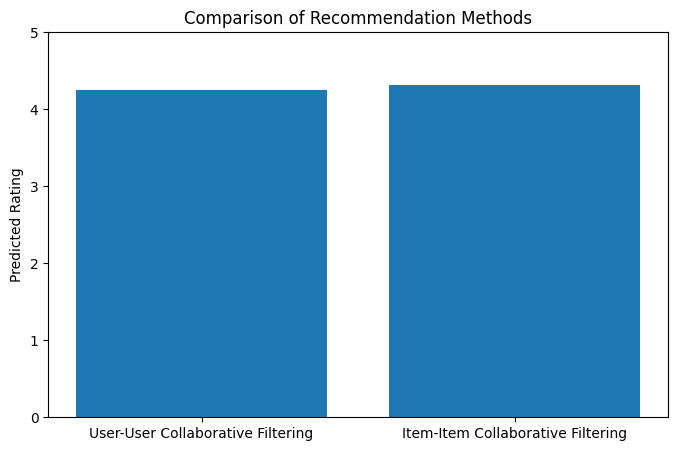

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Predicted Rating"]
)

plt.title("Comparison of Recommendation Methods")
plt.ylabel("Predicted Rating")
plt.ylim(0, 5)

plt.show()

### Interpretation

The graph shows that both recommendation methods produced similar recommendation scores. Item-Item Collaborative Filtering generated a slightly higher predicted rating than User-User Collaborative Filtering, but both approaches suggest that Queen Charlotte would be a strong recommendation for Kevin.

## Advantages and Limitations

### User-User Collaborative Filtering

Advantages:
- Easy to understand and explain.
- Recommendations are based on users with similar preferences.
- Can provide personalized recommendations.

Limitations:
- Requires enough user ratings to identify similar users.
- Recommendations may be less reliable if users have rated only a small number of items.
- Similar users may not always have rated the same items.

### Item-Item Collaborative Filtering

Advantages:
- Often provides stable recommendations because item relationships change less frequently than user preferences.
- Can scale well when the number of users becomes very large.
- Recommendations are based on items the user has already enjoyed.

Limitations:
- Requires enough ratings to identify meaningful item similarities.
- New items may not have enough ratings to establish similarity relationships.
- Similar rating patterns do not necessarily mean that items share similar content or themes.

## Summary

This project explored two collaborative filtering approaches: User-User Collaborative Filtering and Item-Item Collaborative Filtering.

The User-User approach identified users with rating patterns similar to Kevin and used their ratings to estimate how much Kevin would enjoy an unrated item. This method produced a predicted rating of approximately 4.25 for Queen Charlotte.

The Item-Item approach examined the relationship between Queen Charlotte and other shows Kevin had already rated. Using item similarities and Kevin's existing ratings, this method produced a predicted rating of approximately 4.32.

Although the two methods used different approaches, both produced similar recommendation scores and suggested that Queen Charlotte would be a strong recommendation for Kevin. This project helped demonstrate how collaborative filtering can be used to generate personalized recommendations based on user behavior and rating patterns.

Because I am familiar with many of the shows used in this project, using a simple movie and television dataset made it easier for me to understand the recommendation process and explain how the algorithms generated their recommendations.

## AI Assistance Statement

Artificial intelligence tools were used to assist with brainstorming, code review, debugging, explanations of recommender system concepts, and improving written interpretations within the notebook. All code was reviewed, tested, and modified as needed by the author to ensure understanding of the methods and results presented in this project.